# Random Forest Implementation using a Real-World Business Use Case

## Use Case: Telecom Customer Churn Prediction

In telecom, **customer churn** means a customer stops using the company’s services.

### Business Objective
Predict which customers are likely to churn so the company can:
- reduce customer loss
- improve retention campaigns
- prioritize high-risk customers
- protect recurring revenue

### Technical Objective
Build a **Random Forest Classifier** to predict churn using customer profile, contract details, billing information, and services used.

This notebook is:
- compatible with **Google Colab**
- runnable end-to-end
- suitable for learning, demo, or academic submission


## Step 1: Install and Import Required Libraries

In [1]:
# If needed in Colab, uncomment:
# !pip install -q scikit-learn joblib pandas matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

## Step 2: Load a Real-World Dataset

We use the **IBM Telco Customer Churn** dataset from a public source.

### Target variable
- `Churn`: Yes or No


In [4]:
# url = "https://raw.githubusercontent.com/blastchar/telco-customer-churn/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3: Explore the Data

In [5]:
df.info()

print("\nMissing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nTarget distribution:")
print(df["Churn"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Step 4: Data Cleaning

`TotalCharges` may contain blanks, so we convert it to numeric and mark invalid values as missing.
We also convert `Churn` into binary format.


In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df[["TotalCharges", "Churn"]].head())
print("\nMissing values after conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])

   TotalCharges  Churn
0         29.85      0
1       1889.50      0
2        108.15      1
3       1840.75      0
4        151.65      1

Missing values after conversion:
TotalCharges    11
dtype: int64


## Step 5: Define Features and Target

In [7]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (7043, 19)
Target shape: (7043,)


## Step 6: Identify Numeric and Categorical Columns

In [8]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumeric columns:", numeric_cols)

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


## Step 7: Build the Preprocessing Pipeline

- Numeric columns: fill missing values with median
- Categorical columns: fill missing values with most frequent value, then one-hot encode


In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

## Step 8: Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (5634, 19)
X_test : (1409, 19)


## Step 9: Create the Random Forest Model

Random Forest is useful because it:
- combines many decision trees
- reduces overfitting compared to a single tree
- handles non-linear patterns well
- performs strongly on structured business data


In [11]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    class_weight="balanced"
)

## Step 10: Build the Full Pipeline and Train the Model

In [12]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", rf_model)
])

model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


## Step 11: Make Predictions

In [13]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("First 10 predictions:", y_pred[:10])
print("First 10 probabilities:", y_proba[:10])

First 10 predictions: [0 1 0 0 0 1 1 0 0 1]
First 10 probabilities: [0.01990437 0.82068948 0.13167563 0.49082015 0.04843094 0.76411327
 0.56140102 0.17851077 0.00816253 0.57042068]


## Step 12: Evaluate Model Performance

In [14]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy  : {accuracy:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy  : 0.7658
ROC-AUC   : 0.8415

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



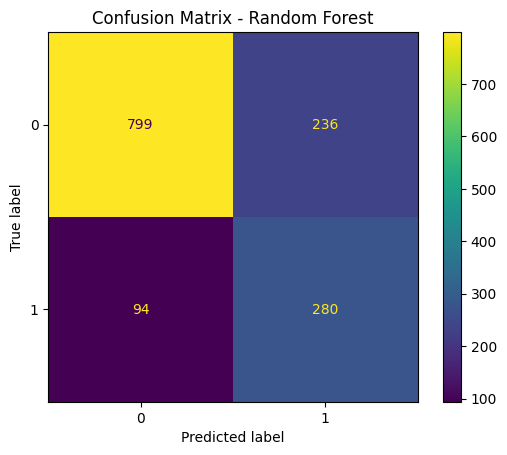

In [15]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

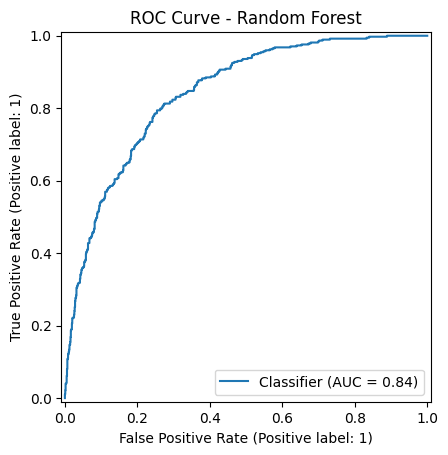

In [16]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - Random Forest")
plt.show()

## Step 13: Feature Importance

This helps the business understand which factors influence churn most.


In [17]:
fitted_preprocessor = model.named_steps["preprocessor"]
fitted_classifier = model.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_classifier.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
36,cat__Contract_Month-to-month,0.132770
1,num__tenure,0.124240
3,num__TotalCharges,0.098327
2,num__MonthlyCharges,0.068761
38,cat__Contract_Two year,0.065866
18,cat__OnlineSecurity_No,0.063543
27,cat__TechSupport_No,0.049503
16,cat__InternetService_Fiber optic,0.049256
43,cat__PaymentMethod_Electronic check,0.036100
37,cat__Contract_One year,0.019888


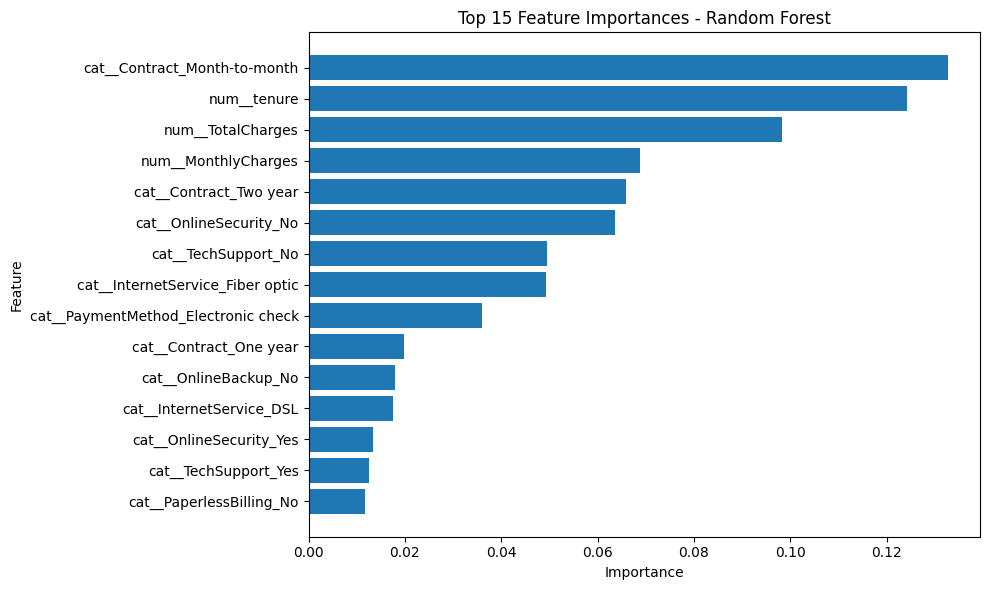

In [18]:
top_n = 15
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

## Step 14: Predict for a New Customer

Now we simulate a real business scenario for the retention team.


In [19]:
new_customer = pd.DataFrame([{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 12,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 89.50,
    "TotalCharges": 1074.00
}])

new_pred = model.predict(new_customer)[0]
new_prob = model.predict_proba(new_customer)[0, 1]

print("Predicted Churn Class:", "Yes" if new_pred == 1 else "No")
print(f"Probability of Churn: {new_prob:.2%}")

Predicted Churn Class: Yes
Probability of Churn: 82.69%


## Step 15: Business Interpretation

If churn probability is high, the company can:
- offer a retention discount
- trigger a support callback
- recommend a long-term contract
- prioritize the customer in a save campaign

### Business value
This supports:
- lower attrition
- higher customer lifetime value
- smarter use of retention budgets
- better data-driven decision-making


## Step 16: Save the Trained Model

In [20]:
joblib.dump(model, "random_forest_churn_model.pkl")
print("Model saved as random_forest_churn_model.pkl")

Model saved as random_forest_churn_model.pkl


## Conclusion

We implemented **Random Forest** for a real-world business problem: **telecom customer churn prediction**.

Covered in this notebook:
- real business use case
- data loading
- preprocessing
- Random Forest training
- evaluation
- feature importance
- new customer prediction
- model saving
